## Lookup Table generálása a kimeneti függvényekhez

Elsőször megvizsgáltam a dokumentációban ([https://github.com/Marco-Winzker/NN_RGB_FPGA/tree/master](https://github.com/Marco-Winzker/NN_RGB_FPGA/tree/master)) szereplő sigmoid függvényt.

In [2]:
from matplotlib import pyplot as plt
import numpy as np
from collections import Counter

In [108]:
with open("sigmoid", "r") as f:
    lines = f.readlines()
    sigmoid_values = []
    for line in lines:
        parts = line.split(":")
        if len(parts) > 1:
            value_part = parts[1].strip().rstrip(";")
            try:
                value = int(value_part)
                sigmoid_values.append(value)
            except ValueError:
                continue

plt.plot(sigmoid_values)
plt.title("Sigmoid lookup table")
plt.xlabel("Input index")
plt.ylabel("Quantized sigmoid value")
plt.show()

from collections import Counter
value_counts = Counter(sigmoid_values)
for value, count in value_counts.items():
    print(f"Érték: {value}, Darabszám: {count}")

FileNotFoundError: [Errno 2] No such file or directory: 'sigmoid'

### Alább az öt darab aktivációs függvény megvalósítása LUT-okkal

Sigmoid: 

In [53]:
my_sigmoid = {}

#size = 256
#scale = 256

#for i in range(0, size):
#    my_sigmoid[i] = int( (1 / (1 + np.exp(-((i - (size/2)) / (size/16+size/32))))) * scale )

import torch

## ezek a parameterek a bitszelesseg
inwidth = int(np.exp2(19))
outwidth = int(np.exp2(19))
beta = (2**10) # ezekk a 2^(int_scale+weight_scale) # 6 + 4 = 0
def sigmoid_generator(inwidth, outwidth, beta):
    my_sigmoid = {}

    inwidth = int(np.exp2(inwidth))
    outwidth = int(np.exp2(outwidth))
    beta = (2**beta) # ezekk a 2^(int_scale+weight_scale) # 6 + 4 = 0

    for i in range(round(-inwidth/2), round(inwidth/2)):
        my_sigmoid[i] = beta/(1 + np.exp(-i/beta)) 

    
    plt.plot(list(my_sigmoid.values()))
    plt.title("My Sigmoid approximation")
    plt.xlabel("Input index")
    plt.ylabel("Quantized sigmoid value")
    plt.grid()
    plt.show()

    with open("my_sgimoid_lookup_table.txt", "w") as f:
        for key in sorted(my_sigmoid.keys()):
            f.write(f"{my_sigmoid[key]},\n")

    offset = inwidth//2
    new_d = {k + offset: v for k, v in my_sigmoid.items()}
    my_sigmoid = new_d
    len(my_sigmoid)//2

    return my_sigmoid

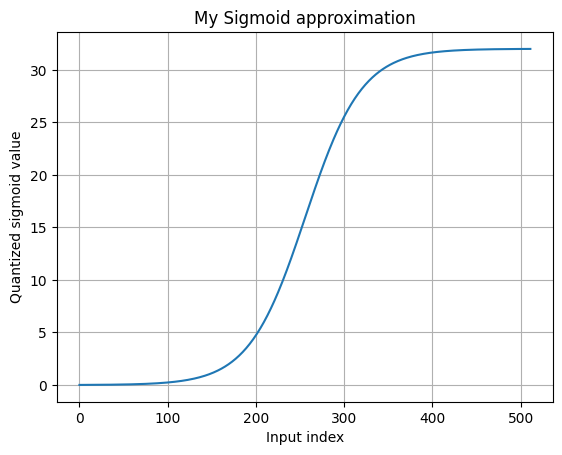

In [37]:
my_sigmoid={}
inwidth = int(np.exp2(9))
outwidth = int(np.exp2(9))
beta = (2**5) # ezekk a 2^(int_scale+weight_scale) # 6 + 4 = 0

for i in range(round(-inwidth/2), round(inwidth/2)):
    my_sigmoid[i] = beta/(1 + np.exp(-i/beta)) 

   
plt.plot(list(my_sigmoid.values()))
plt.title("My Sigmoid approximation")
plt.xlabel("Input index")
plt.ylabel("Quantized sigmoid value")
plt.grid()
plt.show()

Relu:

In [38]:
relu_table = {}
for i in range(size):
    relu_table[i] = max(0, int((i - (size/2)) / 2**(np.log2(size)-np.log2(scale)-1)))

plt.plot(list(relu_table.values()))
plt.title("ReLU lookup table")
plt.xlabel("Input index")
plt.ylabel("Quantized ReLU value")
plt.show()

with open("relu_lookup_table.txt", "w") as f:
    for key in sorted(relu_table.keys()):
        f.write(f"{relu_table[key]},\n")

NameError: name 'size' is not defined

Softplus:

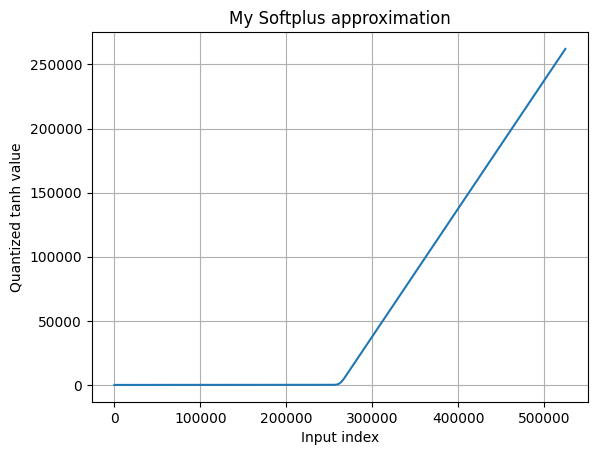

1370
15
0


262144

In [39]:
# Softplus LUT
import numpy as np
import torch
from torch import nn

## ezek a parameterek a bitszelesseg
inwidth = int(np.exp2(19))
outwidth = int(np.exp2(19))
beta = 1/(2**11) # ezekk a 2^(int_scale+weight_scale) ##

my_softplus = {}
for i in range(round(-inwidth/2), round(inwidth/2)):
    my_softplus[i] = round( (1/beta) * np.log( 1 + np.exp( beta * i)) )

"""
my_softplus = {}
for i in range(-128, 128):
    my_softplus[i] = min(scale-1, max(0, int(np.log(1 + np.exp((i)/size*8))*scale/4)))
"""
    
plt.plot(list(my_softplus.values()))
plt.title("My Softplus approximation")
plt.xlabel("Input index")
plt.ylabel("Quantized tanh value")
plt.grid()
plt.show()

with open("my_softplus_lookup_table.txt", "w") as f:
    for key in sorted(my_softplus.keys()):
        f.write(f"{my_softplus[key]},\n")

print(my_softplus[-100])
print(my_softplus[-10000])
print(my_softplus[-inwidth//2])

offset = inwidth//2
new_d = {k + offset: v for k, v in my_softplus.items()}
my_softplus = new_d
len(my_softplus)//2

Tanh:

In [40]:
my_tanh = {}

for i in range(0, size):
    my_tanh[i] = int(np.tanh((i - size/2) / 2**(np.log2(size)-3)) * scale/2)

plt.plot(list(my_tanh.values()))
plt.title("My Tanh approximation")
plt.xlabel("Input index")
plt.ylabel("Quantized tanh value")
plt.grid()
plt.show()

with open("my_tanh_lookup_table.txt", "w") as f:
    for key in sorted(my_tanh.keys()):
        f.write(f"{my_tanh[key]},\n")

NameError: name 'size' is not defined

Leaky Relu:

In [41]:
my_leaky_relu = {}
for i in range(0, size):
    if i < size/2:
        my_leaky_relu[i] = int(- ((size/2- i) * 2**-8)/2)
    else :
        my_leaky_relu[i] = int((i - (size/2)) / 2**(np.log2(size)-np.log2(scale)-1)/2)

plt.plot(list(my_leaky_relu.values()))
plt.title("Leaky Relu approximation")
plt.xlabel("Input index")
plt.ylabel("Quantized tanh value")
plt.grid()
plt.show()

with open("my_leaky_relu_lookup_table.txt", "w") as f:
    for key in sorted(my_leaky_relu.keys()):
        f.write(f"{my_leaky_relu[key]},\n")

NameError: name 'size' is not defined

#### LUT + Lineáris interpoláció

A Leaky Relu-t és a Relut nem fogom ezzel a megoldással implementálni, mivel mindkét függvény egyszerűen számolhaló az elágazással és a generálási függvénnyel.

In [42]:
num_of_points = 8
param = int(size/num_of_points)
points = {}

x_values = []
y_values = []

print(param)
for i in range(size):
    if i%param == 0:
        x_values.append(i)
        y_values.append(my_sigmoid[i])

x_values.append(size-1)
y_values.append(my_sigmoid[size-1])
print(x_values)
print(y_values)

NameError: name 'size' is not defined

In [ ]:
def generate_pwl_switch(name, activation_values, size, num_of_points, shift):

    param = int(size / num_of_points)
    x_values = []
    y_values = []

    for i in range(size):
        if i % param == 0:
            x_values.append(i)
            y_values.append(activation_values[i])

    # utolsó pont hozzáadása
    x_values.append(size - 1)
    y_values.append(activation_values[size - 1])

    a = []
    b = []
    k_values = []
    segments = []

    for i in range(len(x_values) - 1):
        ai = (y_values[i+1] - y_values[i]) / (x_values[i+1] - x_values[i])
        bi = y_values[i] - ai * x_values[i]
        k = round(ai * (2**shift))
        a.append(ai)
        b.append(int(round(bi)))
        k_values.append(k)
        segments.append((x_values[i], x_values[i+1], ai, bi, k))

    print(f"ap_uint<18> {name}(ap_uint<18> x){{")
    print(f"    int interval = x >> {shift};")
    print(f"    switch (interval){{")

    for idx, (k, bi) in enumerate(zip(k_values, b)):
        print(f"        case {idx}: return ((x * {k}) >> {shift}) + {bi};")

    print("        default: return {255};")
    print("    }    ")
    print("}")    

    return segments

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def plot_pwl_error(activation_values, segments, title="PWL Approximation Error"):

    # diszkrét x értékek
    x_all = sorted(activation_values.keys())
    y_orig = np.array([activation_values[x] for x in x_all])

    # PWL értékek kiszámítása diszkréten
    y_pwl = []
    for x in x_all:
        for (x0, x1, a, b, _) in segments:
            if x0 <= x <= x1:
                y_pwl.append(a * x + b)
                break
    y_pwl = np.array(y_pwl)

    # különbség
    diff = y_orig - y_pwl

    # statisztika
    mean_err = np.mean(diff)
    mae = np.mean(np.abs(diff))
    max_err = np.max(np.abs(diff))
    std_err = np.std(diff)

    print("=== PWL Approximation Error Statistics ===")
    print(f"Átlagos hiba      : {mean_err:.6f}")
    print(f"Átlagos absz. hiba: {mae:.6f}")
    print(f"Maximum hiba      : {max_err:.6f}")
    print(f"Szórás            : {std_err:.6f}")

    # plot
    plt.figure(figsize=(10,6))
    plt.plot(x_all, diff, color="red", label="Eredeti - PWL")
    plt.axhline(0, color="black", linestyle="--")
    plt.xlabel("x")
    plt.ylabel("Eltérés")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

ap_uint<18> pwl_sigmoid(ap_uint<18> x){
    int interval = x >> 5.0;
    switch (interval){
        case 0: return ((x * 0) >> 5.0) + 0;
        case 1: return ((x * 0) >> 5.0) + 0;
        case 2: return ((x * 0) >> 5.0) + 0;
        case 3: return ((x * 0) >> 5.0) + 0;
        case 4: return ((x * 0) >> 5.0) + 0;
        case 5: return ((x * 0) >> 5.0) + 0;
        case 6: return ((x * 0) >> 5.0) + 0;
        case 7: return ((x * 0) >> 5.0) + 0;
        case 8: return ((x * 0) >> 5.0) + 0;
        case 9: return ((x * 0) >> 5.0) + 0;
        case 10: return ((x * 0) >> 5.0) + -1;
        case 11: return ((x * 0) >> 5.0) + -4;
        case 12: return ((x * 1) >> 5.0) + -11;
        case 13: return ((x * 2) >> 5.0) + -28;
        case 14: return ((x * 5) >> 5.0) + -63;
        case 15: return ((x * 7) >> 5.0) + -102;
        case 16: return ((x * 7) >> 5.0) + -102;
        case 17: return ((x * 5) >> 5.0) + -58;
        case 18: return ((x * 2) >> 5.0) + -13;
        case 19: return ((

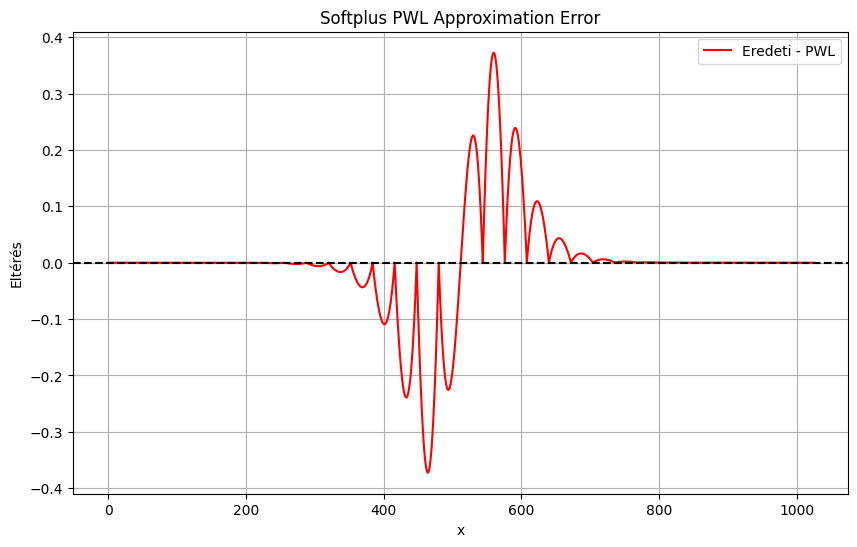

In [49]:
segments = generate_pwl_switch("pwl_sigmoid", my_sigmoid, size=inwidth, num_of_points=32, shift=np.log2(beta))

plot_pwl_error(my_sigmoid, segments, title="Softplus PWL Approximation Error")

In [33]:
print(segments)
for (x0, x1, a, b, k) in segments:
    #print(f"x0: {x0}, x1: {x1}, a: {a}, b: {b}")
    print(f"y = {a}*x + {b}")
    #print(f"k = {k}")
    print(f"((x * {k}) >> 14) + {int(b)}")

x = 7945
print(x+inwidth//2)  # 131072
print((x+inwidth//2) >> 14)

print("bitshifttel")
axb = (((x+inwidth//2) * 512) >> 14) -7679
print(axb)

print("a*x + b formában")
ezis = 0.03124999296655237*(x+inwidth//2) -7679.99
print(ezis)

print("LUT-ból")
print(my_sigmoid[x+inwidth//2])

y = 0.03124999296655237*x + -7679.9981562239045
((x * 512) >> 14) + -7679



#print("PyTorch Softplus paraméteres")
#beta=1/(32*64) # beta = 1/(input_scale*weight_scale)
#actint = nn.Softplus(beta=beta)
#print(actint(torch.tensor([7945.1758])))

[(0, 16384, np.float64(0.0004348570129142429), np.float64(10.988753075125555), 14), (16384, 32768, np.float64(0.0007165451149540917), np.float64(6.373575211304672), 23), (32768, 49152, np.float64(0.0011802621246726926), np.float64(-8.821503763154443), 39), (49152, 65536, np.float64(0.0019428817997955653), np.float64(-46.30578603479388), 64), (65536, 81920, np.float64(0.0031950291185227067), np.float64(-128.3665127148958), 105), (81920, 98304, np.float64(0.0052454264167774555), np.float64(-296.33505938792484), 172), (98304, 114688, np.float64(0.008588183412616648), np.float64(-624.9414431069008), 281), (114688, 131072, np.float64(0.013998534662996758), np.float64(-1245.4438073104948), 459), (131072, 147456, np.float64(0.02265204157852952), np.float64(-2379.676265743205), 742), (147456, 163840, np.float64(0.036227284852420924), np.float64(-4381.427337938136), 1187), (163840, 180224, np.float64(0.05686461368735353), np.float64(-7762.647294253494), 1863), (180224, 196608, np.float64(0.0866

-7431

In [61]:
import numpy as np
import matplotlib.pyplot as plt

def draw_pwl(segments):
    plt.figure(figsize=(10,6))

    # Minden szakaszt kirajzolunk
    for (x0, x1, a, b, k) in segments:
        x = np.linspace(x0, x1)
        y = a * x + b
        plt.plot(x, y, label=f"[{x0:.0f},{x1:.0f}]")
        
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Darabolt lineáris közelítés")
    #plt.legend()
    plt.grid(True)
    plt.show()


In [62]:
def draw_error(original, segments):
    plt.figure(figsize=(10,6))

    # Eredeti sigmoid kirajzolása
    x_orig = sorted(original.keys())
    y_orig = [original[x] for x in x_orig]
    plt.plot(x_orig, y_orig, label="Eredeti (original)", color="black")

    # Közelítés kirajzolása
    for (x0, x1, a, b, k) in segments:
        x = np.linspace(x0, x1, 200)
        y = a * x + b
        plt.plot(x, y, label=f"PWL [{x0:.0f},{x1:.0f}]")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Original vs. darabolt lineáris közelítés")
    #plt.legend()
    plt.grid(True)
    plt.show()

### TODO
+ a kiíratást C++os formába hozni
+ beebrudalni a C++ fileba
+ lineáris interpolációt kézzel!

In [20]:
def lin_interp(x, x_points, y_points):
    for i in range(len(x_points)-1):
        if x_points[i] <= x <= x_points[i+1]:
            m = (y_points[i+1] - y_points[i]) / (x_points[i+1] - x_points[i])
            return y_points[i] + m * (x - x_points[i])
    raise ValueError("x kívül esik az intervallumon")

# Példa:
x_points = [0, 2048]
y_points = [1.0, 4.0]

print(lin_interp(1024, x_points, y_points))  # ~2.5


2.5


In [21]:
with open("my_tanh_lookup_table.txt") as f:
    vals = [line.strip() for line in f]

with open("tanh_lookup_table.inc", "w") as f:
    f.write("\n".join(vals))

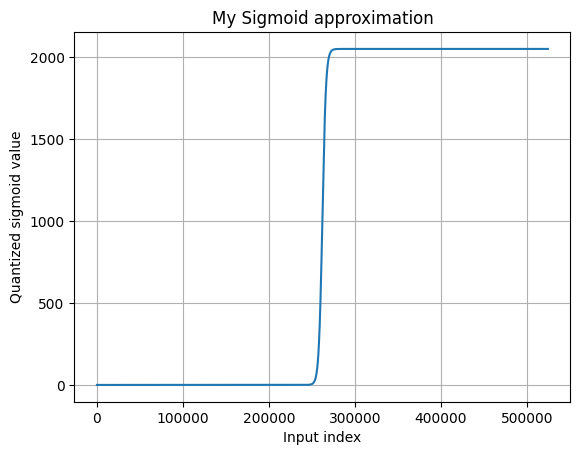

ap_uint<18> pwl_sigmoid(ap_uint<18> x){
    int interval = x >> 11;
    switch (interval){
        case 0: return ((x * 0) >> 11) + 0;
        case 1: return ((x * 0) >> 11) + 0;
        case 2: return ((x * 0) >> 11) + 0;
        case 3: return ((x * 0) >> 11) + 0;
        case 4: return ((x * 0) >> 11) + 0;
        case 5: return ((x * 0) >> 11) + 0;
        case 6: return ((x * 0) >> 11) + 0;
        case 7: return ((x * 0) >> 11) + 0;
        case 8: return ((x * 0) >> 11) + 0;
        case 9: return ((x * 0) >> 11) + 0;
        case 10: return ((x * 0) >> 11) + 0;
        case 11: return ((x * 0) >> 11) + 0;
        case 12: return ((x * 0) >> 11) + 0;
        case 13: return ((x * 0) >> 11) + 0;
        case 14: return ((x * 0) >> 11) + -10;
        case 15: return ((x * 128) >> 11) + -15349;
        case 16: return ((x * 128) >> 11) + -15349;
        case 17: return ((x * 0) >> 11) + 2036;
        case 18: return ((x * 0) >> 11) + 2048;
        case 19: return ((x * 0) >> 11) + 

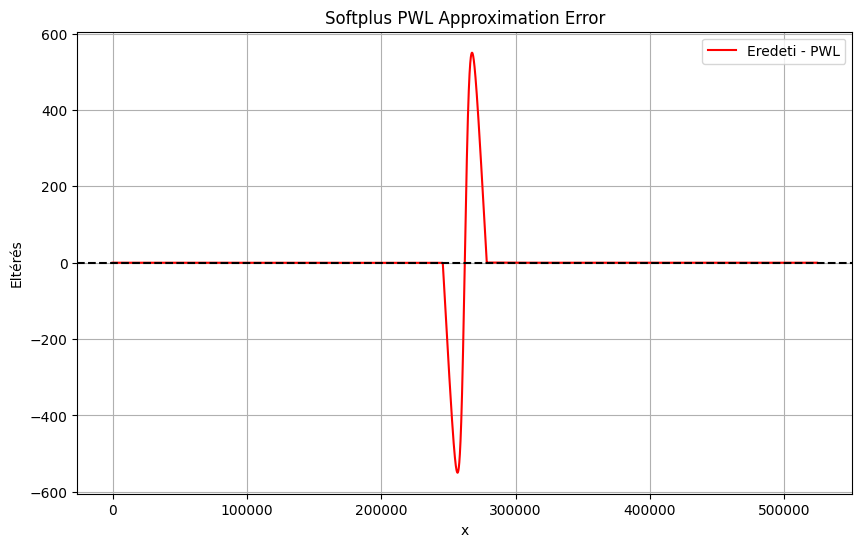

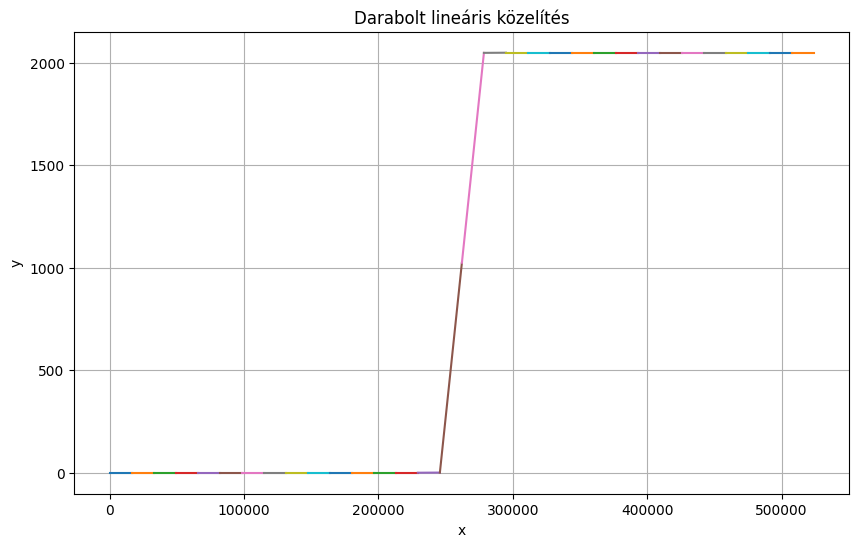

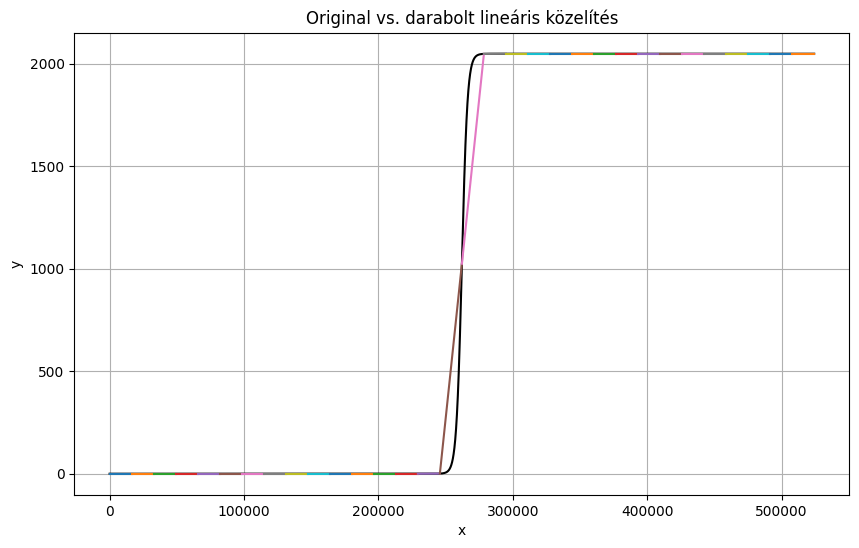

In [72]:
inwidth = 19
outwidth = 19
beta = 11

my_sigmoid = sigmoid_generator(inwidth, outwidth, beta)
segments = generate_pwl_switch("pwl_sigmoid", my_sigmoid, size=int(np.exp2(inwidth)), num_of_points=32, shift=beta)
plot_pwl_error(my_sigmoid, segments, title="Softplus PWL Approximation Error")
draw_pwl(segments)
draw_error(my_sigmoid, segments)